Dataset shape: (178, 14)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  prol

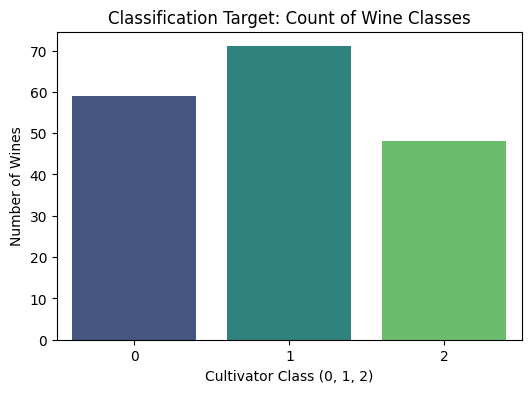

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
import warnings
warnings.filterwarnings('ignore')

# 1. Load the Wine dataset
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target_class'] = wine.target  # Our 3 categories: 0, 1, or 2

print(f"Dataset shape: {wine_df.shape}")
print(wine_df.head())

# 2. Visually confirm it's classification (Distinct Categories)
plt.figure(figsize=(6, 4))
sns.countplot(x='target_class', data=wine_df, palette='viridis')
plt.title("Classification Target: Count of Wine Classes")
plt.xlabel("Cultivator Class (0, 1, 2)")
plt.ylabel("Number of Wines")
plt.show()

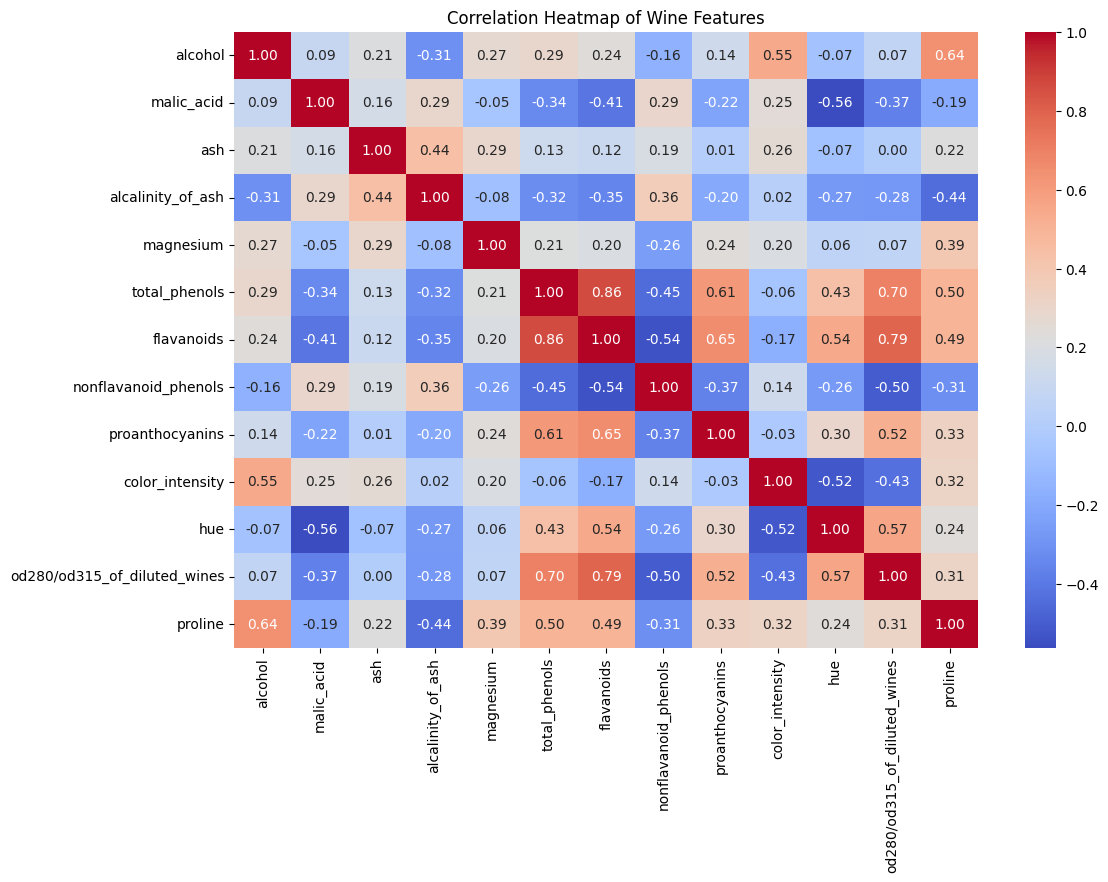


Identified Columns that need to be dropped: ['flavanoids']
['flavanoids'] removed from dataframe.



In [3]:
# 3. Create correlation matrix (excluding the target for this step)
features_only = wine_df.drop('target_class', axis=1)
corr_matrix = features_only.corr().abs()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(features_only.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Wine Features")
plt.show()

# 4. Identify and drop highly correlated features (Threshold > 0.8)
upper = corr_matrix.where(
    ~np.tril(np.ones(corr_matrix.shape)).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print(f"\nIdentified Columns that need to be dropped: {to_drop}")

# Create finalized dataframe
finalised_wine_df = wine_df.drop(columns=to_drop)
print(f"{to_drop} removed from dataframe.\n")

In [4]:
from sklearn.model_selection import train_test_split

# Separate Features (X) and Target (y)
X = finalised_wine_df.drop('target_class', axis=1)
y = finalised_wine_df['target_class']

# Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} wines, testing on {X_test.shape[0]} wines.")

Training on 142 wines, testing on 36 wines.


In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize the classification model
model = LogisticRegression(max_iter=10000)

# Train the model
model.fit(X_train, y_train)
print("\nLogistic Regression Model trained successfully!")


Logistic Regression Model trained successfully!


In [6]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the unseen test data
predictions = model.predict(X_test)

# Calculate Accuracy (Percentage of correct guesses)
accuracy = accuracy_score(y_test, predictions)

print("\n=== Model Evaluation ===")
print(f"Accuracy Score: {accuracy * 100:.2f}%")

# Let's compare the first 5 predictions to the actual answers
comparison = pd.DataFrame({'Actual Class': y_test.head(), 'Predicted Class': predictions[:5]})
print("\nFirst 5 Predictions:")
print(comparison)


=== Model Evaluation ===
Accuracy Score: 100.00%

First 5 Predictions:
     Actual Class  Predicted Class
19              0                0
45              0                0
140             2                2
30              0                0
67              1                1


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the Decision Tree
# We set a random_state for reproducibility. 
tree_model = DecisionTreeClassifier(random_state=42)

# 2. Train the model
# Notice we can just use the unscaled X_train here, but using X_train_scaled works perfectly fine too!
tree_model.fit(X_train, y_train)
print("\nDecision Tree trained successfully!")

# 3. Predict and Evaluate
tree_predictions = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_predictions)

print(f"Decision Tree Accuracy Score: {tree_accuracy * 100:.2f}%")


Decision Tree trained successfully!
Decision Tree Accuracy Score: 91.67%


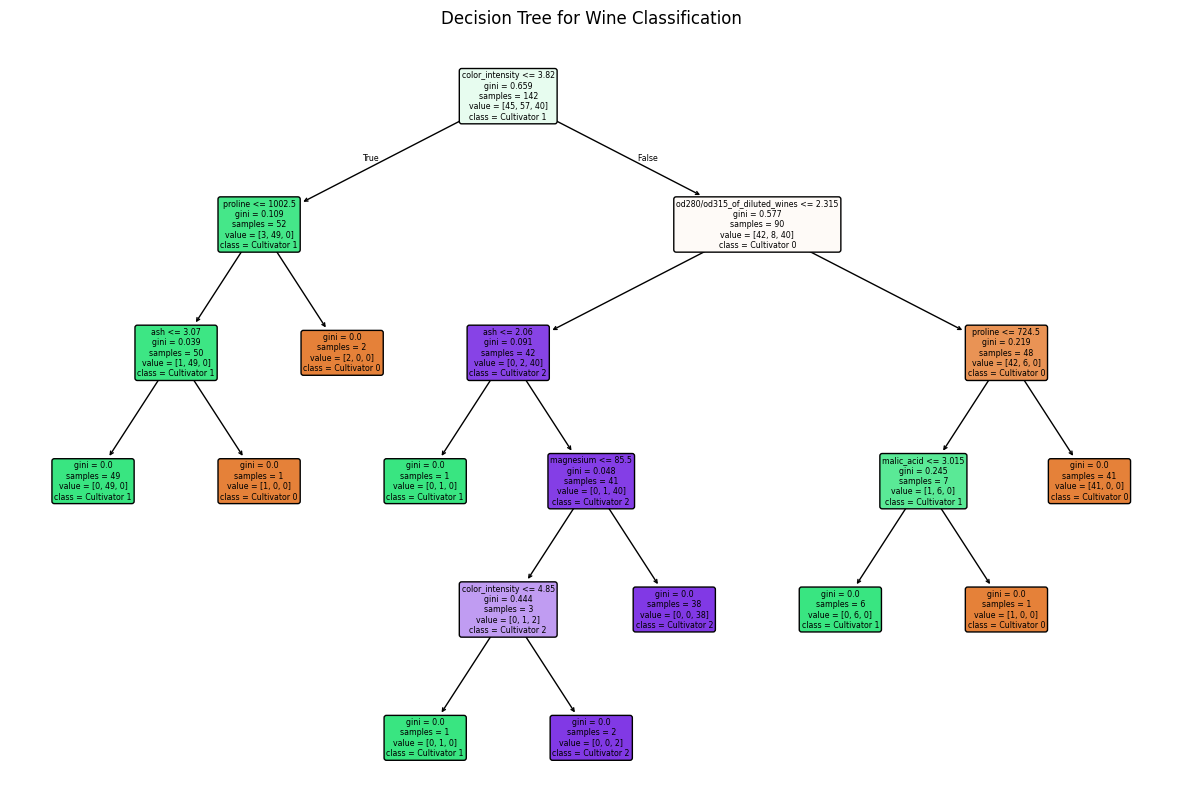

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Draw the tree
plot_tree(tree_model, 
          feature_names=X.columns, 
          class_names=['Cultivator 0', 'Cultivator 1', 'Cultivator 2'], 
          filled=True, 
          rounded=True)

plt.title("Decision Tree for Wine Classification")
plt.show()